Has it become more dangerous to be a pedestrian in Germany, with regards to traffic accidents.


In [46]:
import matplotlib.pyplot as plt

import fetch_data as fd

In [47]:
REPORT_YEARS = [2021, 2022, 2023, 2024]
report_dict = fd.get_dfs(REPORT_YEARS)

We begin by reporting the total number of accidents involving pedestrians for each year


In [48]:
ped_accident_totals: dict[int, int] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    ped_accident_totals[year] = df_yr[(df_yr["IstFuss"] == 1)].shape[0]

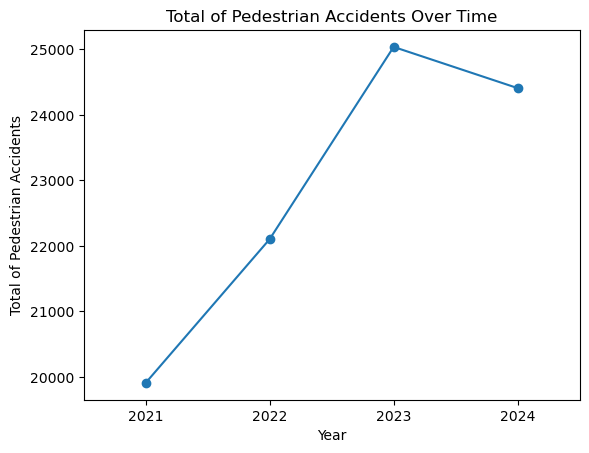

In [49]:
plt.plot(ped_accident_totals.keys(), ped_accident_totals.values(), marker="o")  # type: ignore
plt.title("Total of Pedestrian Accidents Over Time")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Total of Pedestrian Accidents")  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_totals.keys()))  # type: ignore
plt.show()  # type: ignore

We note that there is a drastic uptick in the total number of accidents involving pedestrians. However, this could be early covid ending and more people transiting again as with pre-2020. We analyze the number of accidents involving pedestrians as a proportion of the total accidents below.


In [50]:
ped_accident_prop: dict[int, float] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    total_acc = df_yr.shape[0]
    total_acc_ped = df_yr[(df_yr["IstFuss"] == 1)].shape[0]
    ped_accident_prop[year] = total_acc_ped / total_acc if total_acc > 0 else 0

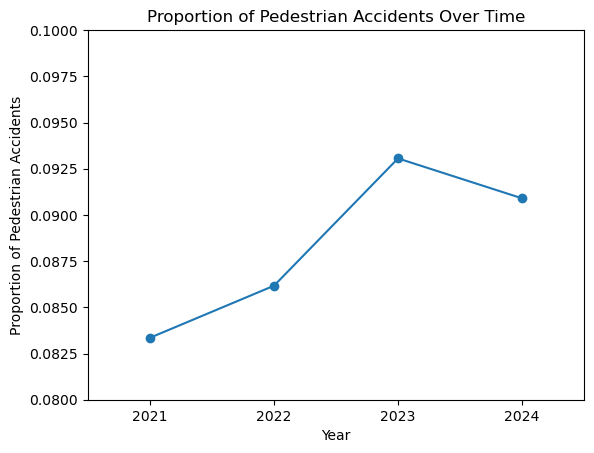

In [51]:
plt.plot(ped_accident_prop.keys(), ped_accident_prop.values(), marker="o")  # type: ignore
plt.title("Proportion of Pedestrian Accidents Over Time")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Proportion of Pedestrian Accidents")  # type: ignore
plt.ylim(0.08, 0.1)  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_prop.keys()))  # type: ignore
plt.show()  # type: ignore

In [52]:
prop_2021 = ped_accident_prop[2021] * 100
prop_2023 = ped_accident_prop[2023] * 100
print(f"Lowest Proportion: {prop_2021:0.1f}%, Highest Proportion: {prop_2023:0.1f}%")

Lowest Proportion: 8.3%, Highest Proportion: 9.3%


In [53]:
pct_change = (prop_2023 - prop_2021) / prop_2021 * 100
print(f"Percentage Change: {pct_change:0.1f}%")

Percentage Change: 11.6%


In [54]:
pct_2024 = ped_accident_prop[2024] * 100
pct_change = (pct_2024 - prop_2021) / prop_2021 * 100
print(f"Percentage Change: {pct_change:0.1f}%")

Percentage Change: 9.1%


Unlike with bicycle accidents, where the proportion of accidents involving bicycles is relatively constant year to year, we see a 1% increase in the share of accidents involving pedestrians between 2021 and 2023. This is equivalent to an 11.6% change in the same timespan. While the proportion of accidents involving pedestrians fell in 2024, we still see a 9.1% increase in the years 2021-2024.


In [55]:
ped_accident_serious_fatal_totals: dict[int, int] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    ped_accident_serious_fatal_totals[year] = df_yr[
        (df_yr["IstFuss"] == 1) & (df_yr["UKATEGORIE"] < 3)
    ].shape[0]

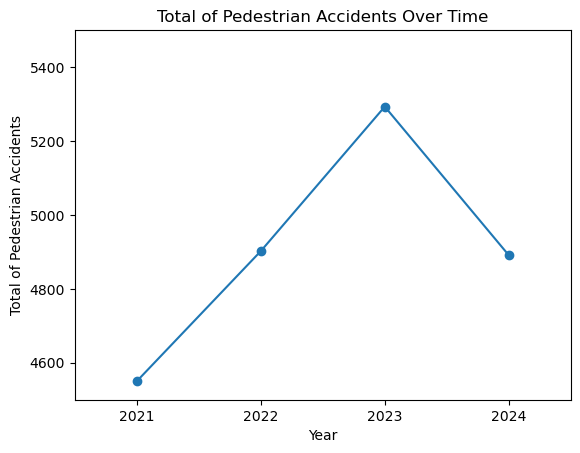

In [56]:
plt.plot(  # type: ignore
    ped_accident_serious_fatal_totals.keys(),  # type: ignore
    ped_accident_serious_fatal_totals.values(),  # type: ignore
    marker="o",
)
plt.title("Total of Pedestrian Accidents Over Time")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Total of Pedestrian Accidents")  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.ylim(4500, 5500)  # type: ignore
plt.xticks(REPORT_YEARS)  # type: ignore
plt.show()  # type: ignore

Again, this seems like a sharp increase but is there really an uptick in the proportion of pedestrian accidents that are serious or fatal?


In [57]:
ped_accident_serious_fatal_prop: dict[int, float] = {
    year: ped_accident_serious_fatal_totals[year] / ped_accident_totals[year]
    for year in REPORT_YEARS
}

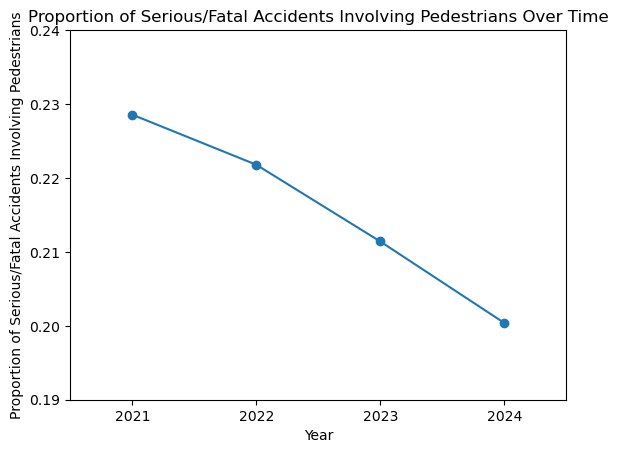

In [58]:
plt.plot(ped_accident_serious_fatal_prop.keys(), ped_accident_serious_fatal_prop.values(), marker="o")  # type: ignore
plt.title("Proportion of Serious/Fatal Accidents Involving Pedestrians Over Time")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Proportion of Serious/Fatal Accidents Involving Pedestrians")  # type: ignore
plt.ylim(0.19, 0.24)  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_serious_fatal_prop.keys()))  # type: ignore
plt.show()  # type: ignore

In [59]:
prop_2021 = ped_accident_serious_fatal_prop[2021] * 100
prop_2024 = ped_accident_serious_fatal_prop[2024] * 100

pct_change = (prop_2024 - prop_2021) / prop_2021 * 100
print(f"Percentage Change: {pct_change:0.1f}%")

Percentage Change: -12.3%


What we actually find is that the proportion of accidents involving pedestrians that result in serious for fatal injury has decreased by 12.3% over the last 4 years. Breaking down the categories further, we find the following:


In [65]:
ped_accident_serious_prop: dict[int, float] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    total_acc = ped_accident_totals[year]
    total_acc_ped_serious = df_yr[
        (df_yr["IstFuss"] == 1) & (df_yr["UKATEGORIE"] == 2)
    ].shape[0]
    ped_accident_serious_prop[year] = (
        total_acc_ped_serious / total_acc if total_acc > 0 else 0
    )

In [66]:
ped_accident_fatal_prop: dict[int, float] = {}

for year in REPORT_YEARS:
    df_yr = report_dict[year]
    total_acc = ped_accident_totals[year]
    total_acc_ped_fatal = df_yr[
        (df_yr["IstFuss"] == 1) & (df_yr["UKATEGORIE"] == 1)
    ].shape[0]
    ped_accident_fatal_prop[year] = (
        total_acc_ped_fatal / total_acc if total_acc > 0 else 0
    )

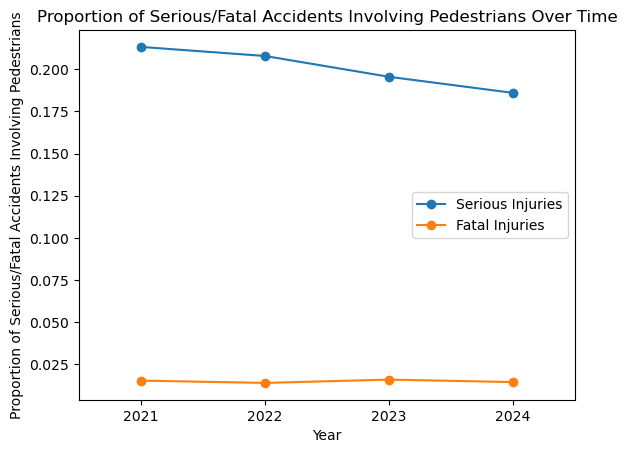

In [67]:
plt.plot(  # type: ignore
    ped_accident_serious_prop.keys(),  # type: ignore
    ped_accident_serious_prop.values(),  # type: ignore
    marker="o",
    label="Serious Injuries",
)
plt.plot(  # type: ignore
    ped_accident_fatal_prop.keys(),  # type: ignore
    ped_accident_fatal_prop.values(),  # type: ignore
    marker="o",
    label="Fatal Injuries",
)

plt.title("Proportion of Serious/Fatal Accidents Involving Pedestrians Over Time")  # type: ignore
plt.xlabel("Year")  # type: ignore
plt.ylabel("Proportion of Serious/Fatal Accidents Involving Pedestrians")  # type: ignore
plt.xlim(2020.5, 2024.5)  # type: ignore
plt.xticks(list(ped_accident_serious_fatal_prop.keys()))  # type: ignore
plt.legend()  # type: ignore
plt.show()  # type: ignore

In [68]:
pct_change_serious = (
    (ped_accident_serious_prop[2024] - ped_accident_serious_prop[2021])
    / ped_accident_serious_prop[2021]
    * 100
)
pct_change_fatal = (
    (ped_accident_fatal_prop[2024] - ped_accident_fatal_prop[2021])
    / ped_accident_fatal_prop[2021]
    * 100
)

print(f"Percentage Change Serious Injuries: {pct_change_serious:0.1f}%")
print(f"Percentage Change Fatal Injuries: {pct_change_fatal:0.1f}%")

Percentage Change Serious Injuries: -12.8%
Percentage Change Fatal Injuries: -5.8%


While the total number of accidents increased, we find that the proportion of accidents involving pedestrians that resulted in a serious injury has decreased by 12.8%. Similarly, the proportion of accidents involving pedestrians that resulted in a fatality has decreased by 5.8%.

While we cannot make any conclusions on the likelihood of being in an accident based on this data, should you be in an accident, you are less likely to be seriously or fatally injured compared to just four years ago.


## Question

Can we create a baysian model to try to predict the severity of pedestrian related accidents? What is likely to be the key indicators? Geo location, time of day, weather? How can we treat a geolocation as a single data point (transformation)?
